### Notebook for Explainable AI for Transformer Architectures

This notebook contains code to get you started on applying explainable AI techniques on your Transformer Model. The code is based on the work described in the paper "XAI for Transformers: Better Explanations through Conservative Propagation" by Ali et al. (2022), to be found here: https://proceedings.mlr.press/v162/ali22a/ali22a.pdf and this is the link to the official repository on Github: https://github.com/AmeenAli/XAI_Transformers

### Imports & loading data

In [3]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import numpy as np

from transformers import pipeline
import seaborn as sns


❗NB: This code works for models based on the BERT architecture. If you used a different transformer architecture (DistilBERT, RoBERTa, etc.), you might need to adapt some of the code to fit the architecutre requirements. 

In [4]:
# Load model and tokenizer
# This is a pre-trained BERT model taken from HuggingFace
#TODO: Insert your own model here! 

tokenizer = AutoTokenizer.from_pretrained(r"pre trained model")
model = AutoModelForSequenceClassification.from_pretrained(r"pre trained model")



In [5]:
id2label = {
    0: "anger",
    1: "disgust", 
    2: "fear",
    3: "happiness",
    4: "neutral",
    5: "sadness",
    6: "surprise"
}

label2id = {v: k for k, v in id2label.items()}

model.config.id2label = id2label
model.config.label2id = label2id

# Now check it worked
print("Updated labels:", model.config.id2label)


Updated labels: {0: 'anger', 1: 'disgust', 2: 'fear', 3: 'happiness', 4: 'neutral', 5: 'sadness', 6: 'surprise'}


## Gradient x Input

The gradient_x_input function calculates token relevance using the Gradient × Input method. It converts input IDs to embeddings and enables gradient tracking. The embeddings are passed through the model, generating logits for prediction. The function computes gradients with respect to the predicted class, indicating how sensitive the prediction is to each token. If no gradients are computed, it raises an error to signal that the embeddings are not properly linked to the output. The gradients are multiplied by the input embeddings to calculate relevance scores, showing how much each token influenced the model’s prediction.

In [6]:
def gradient_x_input(model, inputs):
    inputs_embeds = model.get_input_embeddings()(inputs.input_ids)
    inputs_embeds = inputs_embeds.clone().detach().requires_grad_(True)
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=inputs.attention_mask)
    outputs.logits[:, outputs.logits.argmax()].backward()
    # Fix for NoneType issue — return zero tensor if grad is None
    if inputs_embeds.grad is None:
        raise RuntimeError("Gradients are not computed! Make sure inputs_embeds is correctly passed through the model.")

    return inputs_embeds.grad * inputs_embeds




## Conservative Propagation

The ``modified_attention_forward`` function adjusts attention propagation by calculating attention scores using scaled dot product attention. It computes attention probabilities through softmax, then multiplies them with hidden states to get the context layer. Relevance scores are propagated back through the attention weights, to ensure a conservative flow of information. The ``modified_layernorm_forward`` function normalizes hidden states using the mean and variance, then redistributes relevance based on the normalization values. This follows the paper’s conservative propagation strategy, which stabilizes relevance flow through transformers by correcting how relevance is handled in attention and layer normalization layers.

In [7]:
# Attention Layer - Conservative Propagation
def modified_attention_forward(attention_layer, hidden_states, relevance_scores):
    attention_scores = (hidden_states @ hidden_states.transpose(-1, -2)) / hidden_states.size(-1)**0.5
    attention_probs = attention_scores.softmax(dim=-1).detach()
    context_layer = attention_probs @ hidden_states
    propagated_relevance = (attention_probs.transpose(-1, -2) @ relevance_scores)
    return context_layer, propagated_relevance

# LayerNorm Layer - Conservative Propagation
def modified_layernorm_forward(layernorm_layer, hidden_states, relevance_scores):
    mean = hidden_states.mean(-1, keepdim=True)
    variance = hidden_states.var(-1, keepdim=True, unbiased=False)
    normed = (hidden_states - mean) / (variance + layernorm_layer.eps).sqrt()
    propagated_relevance = relevance_scores / (variance + layernorm_layer.eps).sqrt()
    return normed.detach(), propagated_relevance

### Pertubating

Perturbating means deliberately modifying or disturbing the input data to observe how the model's prediction changes. It helps identify which parts of the input are most influential by measuring the model's sensitivity to these changes. The ``perturb_input_and_evaluate`` function measures how sensitive the model’s prediction is to specific tokens by progressively modifying the input. It first tokenizes the input text and sorts tokens based on their relevance scores. If perturb_type is 'remove', the **least** relevant tokens are removed first; otherwise, the **most relevant** tokens are removed first. Tokens are replaced with [PAD] to maintain input length consistency. The modified texts are converted back into input tensors and passed through the model. The model’s confidence in its prediction is recorded after each perturbation using softmax probabilities. This allows evaluation of how much each token contributes to the final prediction by observing how the model’s confidence changes as tokens are progressively masked.

In [ ]:
#TODO: Play around to see what happens if you remove the least or most relevant tokens first!

def perturb_input_and_evaluate(model, tokenizer, text, inputs, outputs, perturb_type='most'):
    # Get the original prediction
    original_predicted_class = outputs.logits.argmax(dim=-1).item()
    
    # Get relevance scores for this input
    relevance_scores = gradient_x_input(model, inputs)
    
    # Get the input_ids to properly handle special tokens
    input_ids = inputs.input_ids[0]
    
    # Calculate token importance from relevance scores
    token_importance = relevance_scores[0].norm(dim=-1).detach()
    
    # Sort indices by importance
    if perturb_type == 'most':
        # Remove most relevant tokens first (descending order)
        sorted_indices = torch.argsort(token_importance, descending=True)
    else:
        # Remove least relevant tokens first (ascending order)
        sorted_indices = torch.argsort(token_importance, descending=False)
    
    sorted_indices = sorted_indices.tolist()

    confidences = []
    
    # Add the original confidence (0 tokens removed)
    original_probs = outputs.logits.softmax(dim=-1)
    original_confidence = original_probs[0, original_predicted_class].item()
    confidences.append(original_confidence)
    
    # Progressively remove tokens
    for i in range(1, len(input_ids)):
        # Create a copy of input_ids
        perturbed_ids = input_ids.clone()
        
        # Replace tokens with PAD token
        for idx in sorted_indices[:i]:
            if idx < len(perturbed_ids):
                perturbed_ids[idx] = tokenizer.pad_token_id
        
        # Get model output for perturbed input
        perturbed_inputs = {'input_ids': perturbed_ids.unsqueeze(0)}
        pert_output = model(**perturbed_inputs)
        
        # Record confidence for the ORIGINAL predicted class
        probs = pert_output.logits.softmax(dim=-1)
        confidence_original_class = probs[0, original_predicted_class].item()
        confidences.append(confidence_original_class)

    return confidences

## Visualisation of analysis

#### Improved Gradient × Input with Conservative LRP

This code visualizes how much each token contributes to the model’s prediction using the Improved Gradient × Input with Conservative Layer-wise Relevance Propagation. LRP stands for Layer-wise Relevance Propagation. First, the ``gradient_x_input`` function computes relevance scores by calculating the gradient of the predicted class with respect to the input embeddings. These relevance scores show how sensitive the model’s prediction is to each token. The tokens are extracted using the tokenizer and plotted on a bar graph, with the bar height representing the magnitude of the relevance score. Higher bars indicate greater influence on the prediction. 

LRP explains model decisions by tracing relevance scores backward through the network. Basic LRP struggles with transformers due to unstable relevance flow through attention and layer normalization. Conservative LRP improves this by carefully redistributing relevance using attention weights and normalization values, making the explanations more stable, consistent, and accurately reflective of model behavior.

This explanation is labeled as "Improved LRP" because the conservative propagation technique from the paper improves the stability and consistency of relevance flow through the model.


**TODO: Can you explain what the colors represent?**


SENTENCE 1/18
Text: I thought it was fantastic. It was incredibly fun.
Predicted Emotion: happiness


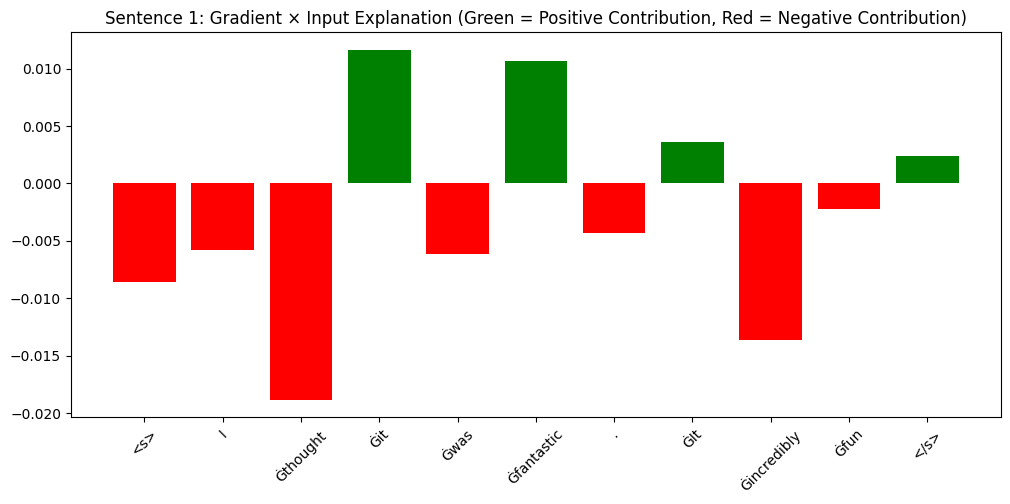


SENTENCE 2/18
Text: A thousand euros! Congratulations.
Predicted Emotion: happiness


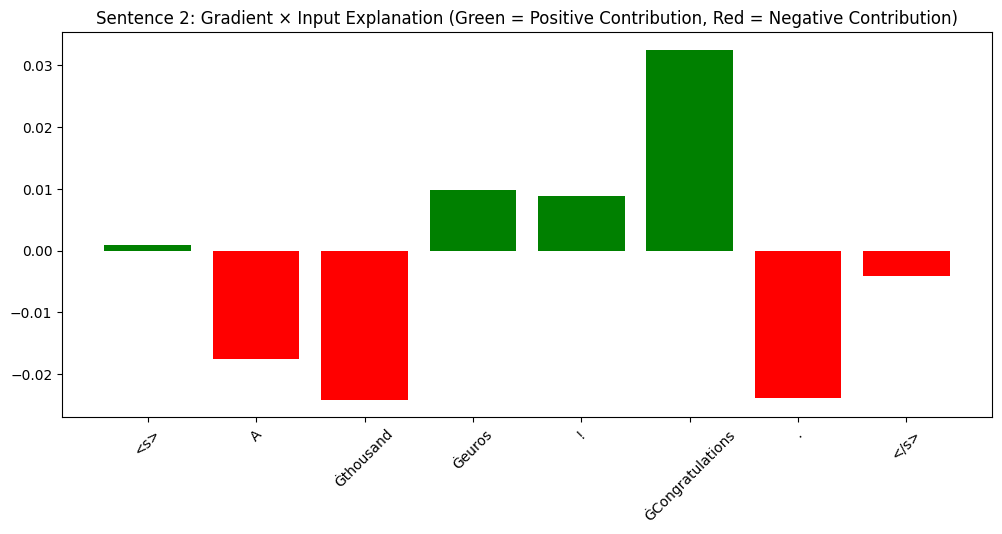


SENTENCE 3/18
Text: I can imagine that you are sitting across from me with a feeling of pride.
Predicted Emotion: happiness


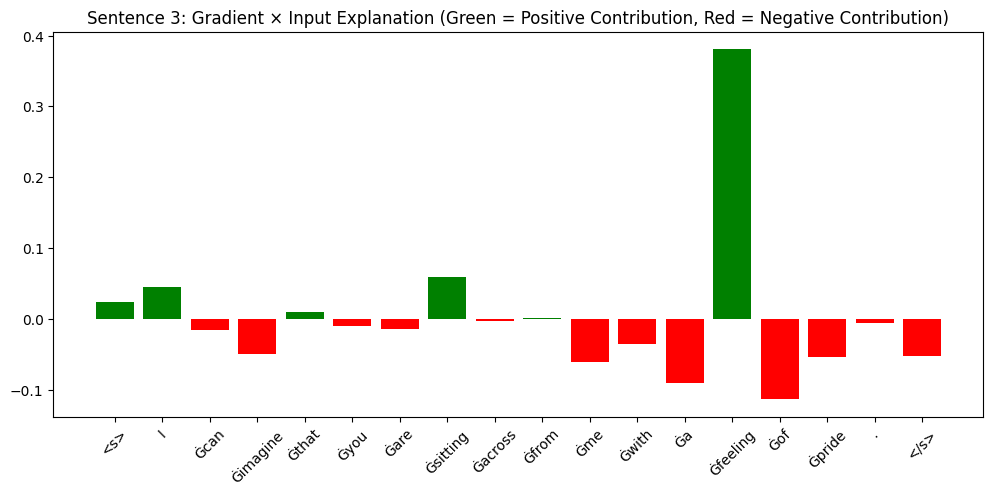


SENTENCE 4/18
Text: With every dropout who leaves, the farewell affects the group value.
Predicted Emotion: neutral


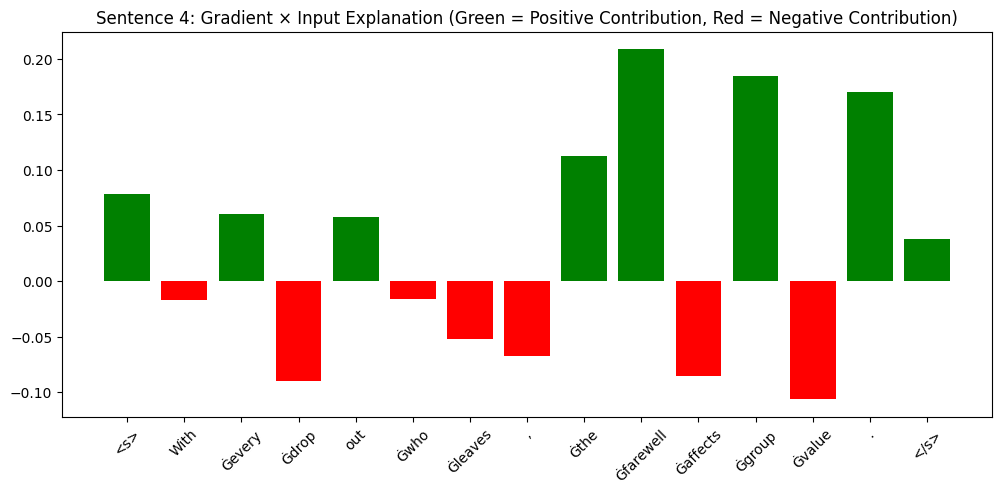


SENTENCE 5/18
Text: Too bad. Yes.
Predicted Emotion: sadness


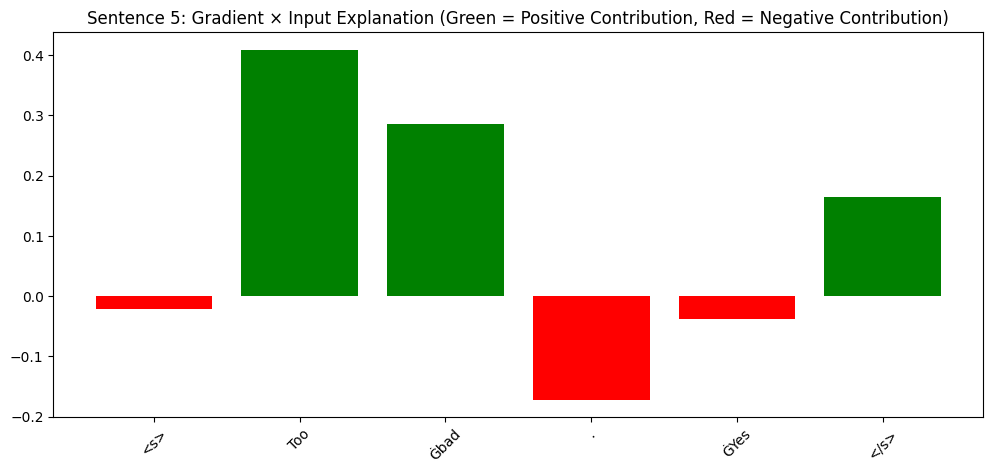


SENTENCE 6/18
Text: Gone as her prime suspect.
Predicted Emotion: neutral


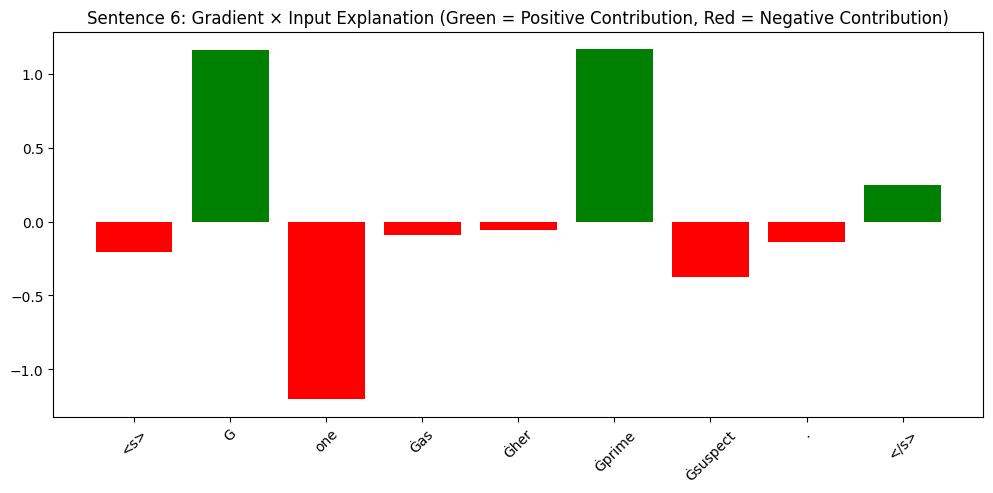


SENTENCE 7/18
Text: You are a dirty sneak.
Predicted Emotion: anger


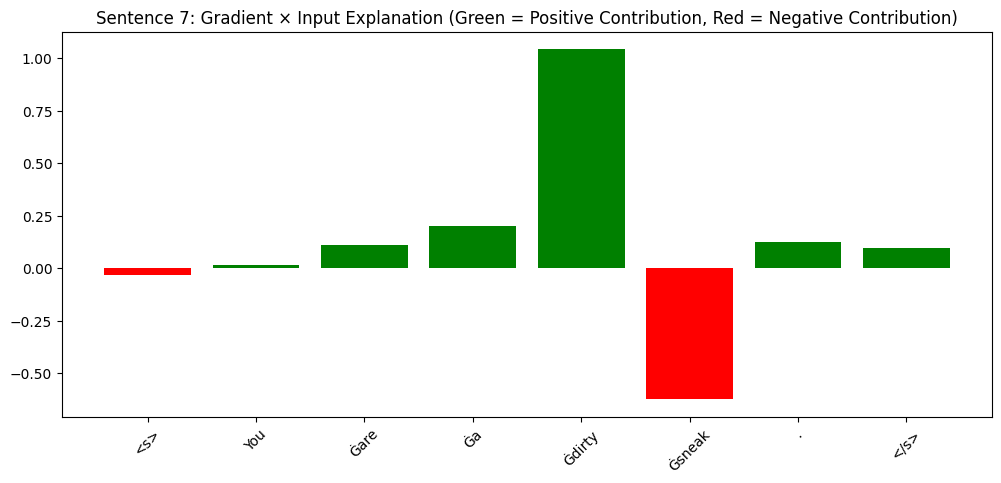


SENTENCE 8/18
Text: Fuck you's.
Predicted Emotion: anger


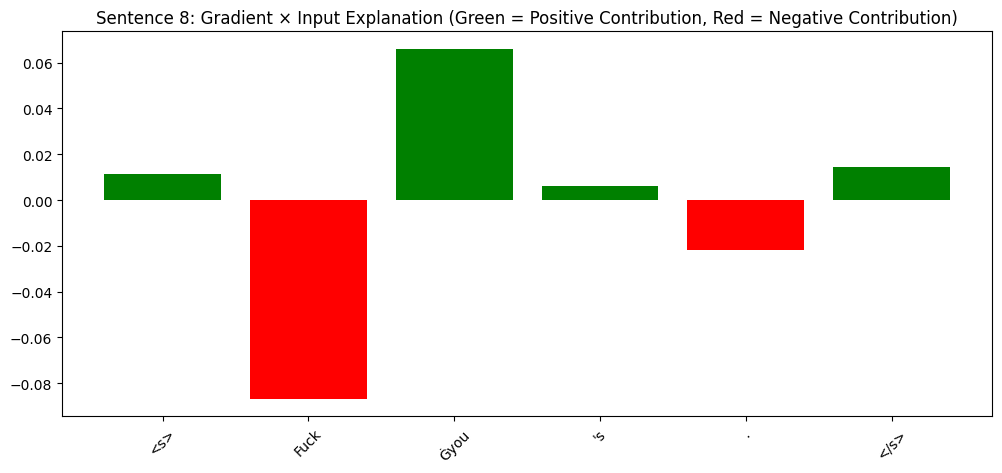


SENTENCE 9/18
Text: I thought you were the bitch.
Predicted Emotion: anger


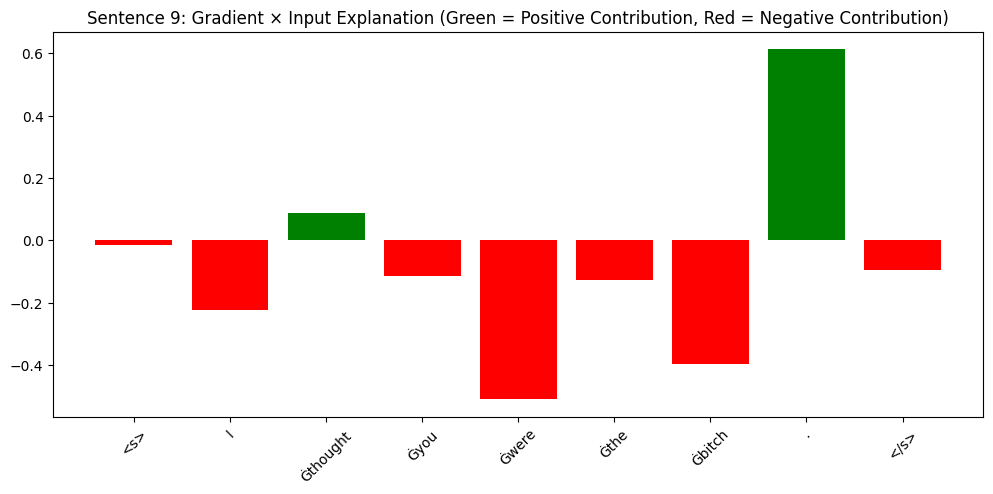


SENTENCE 10/18
Text: fear struck me to the heart.
Predicted Emotion: fear


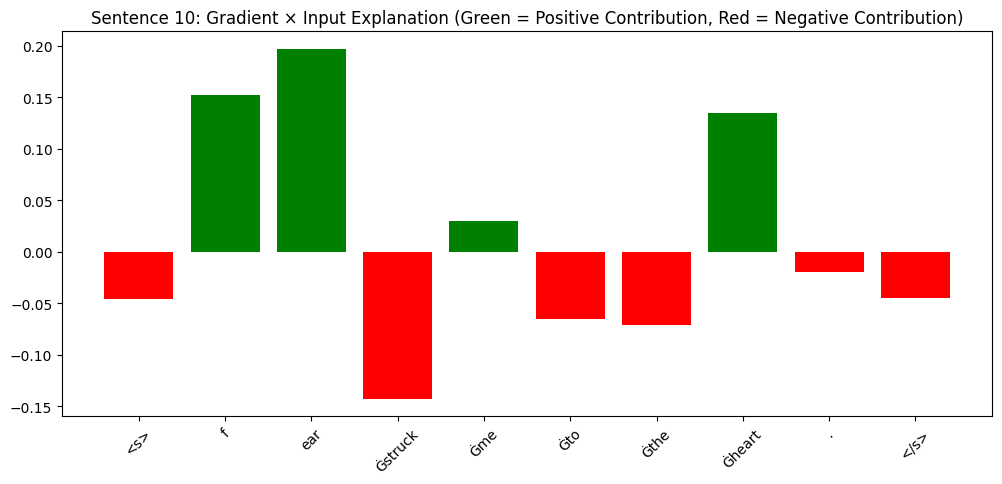


SENTENCE 11/18
Text: Although that is very scary.
Predicted Emotion: fear


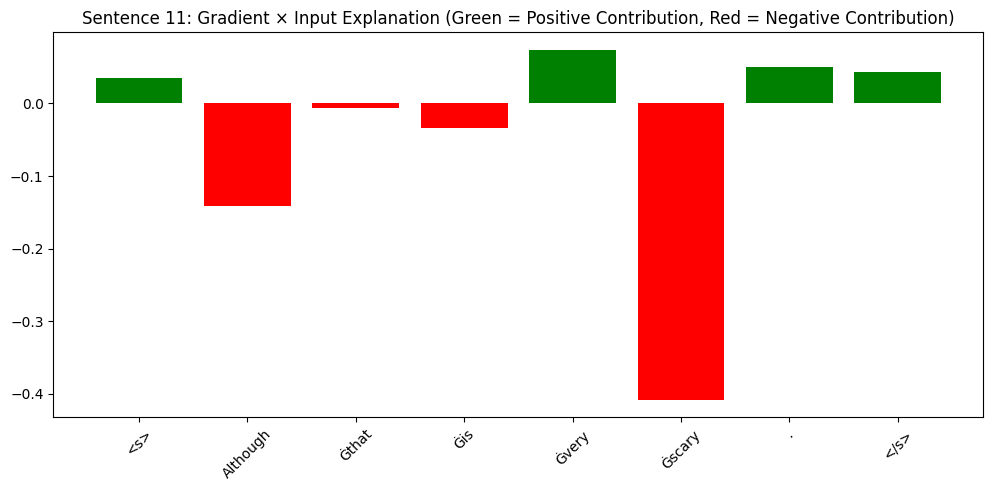


SENTENCE 12/18
Text: I find this a very exciting test.
Predicted Emotion: happiness


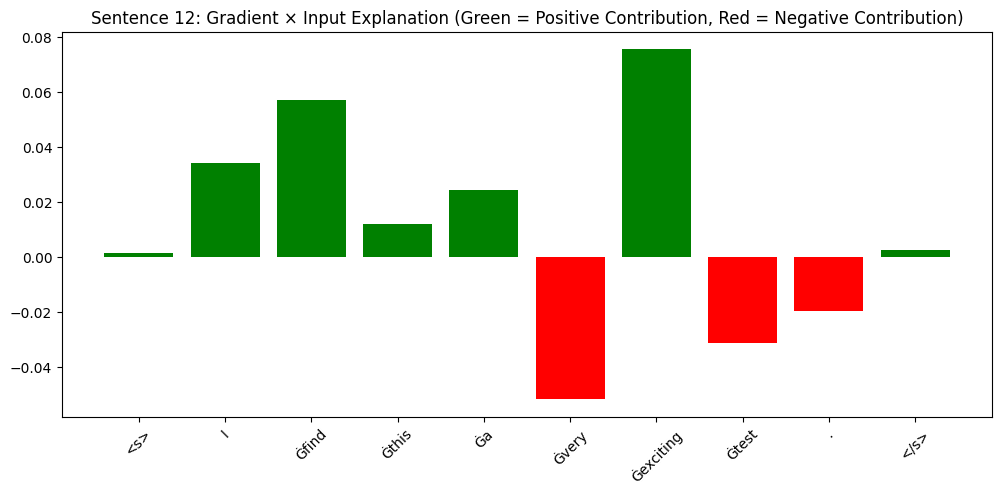


SENTENCE 13/18
Text: Wow. Jeez.
Predicted Emotion: happiness


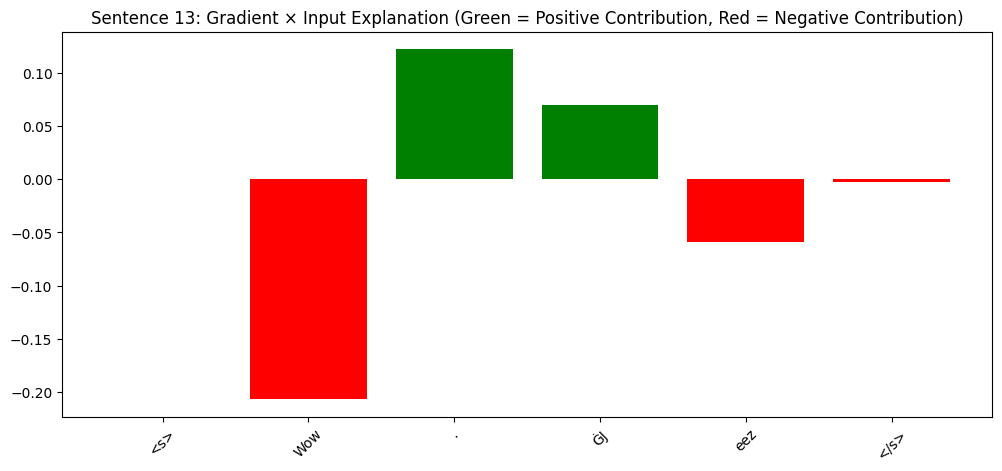


SENTENCE 14/18
Text: Oh my God!
Predicted Emotion: surprise


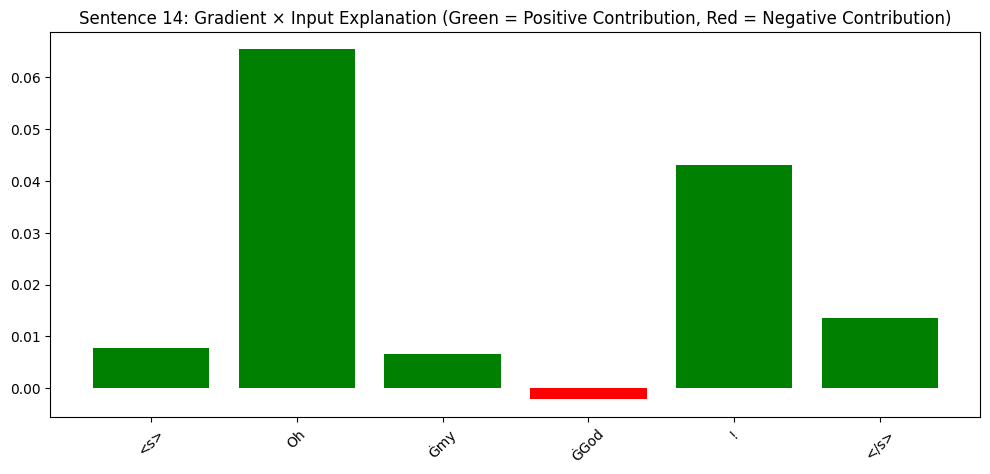


SENTENCE 15/18
Text: Hey wait a minute, Taken is shouting whenever he sees something.
Predicted Emotion: neutral


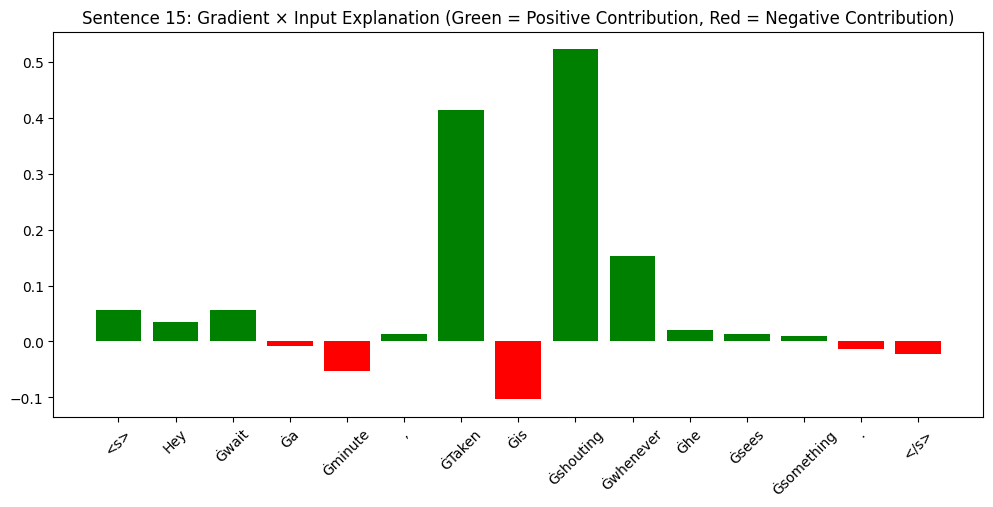


SENTENCE 16/18
Text: Yuck.
Predicted Emotion: disgust


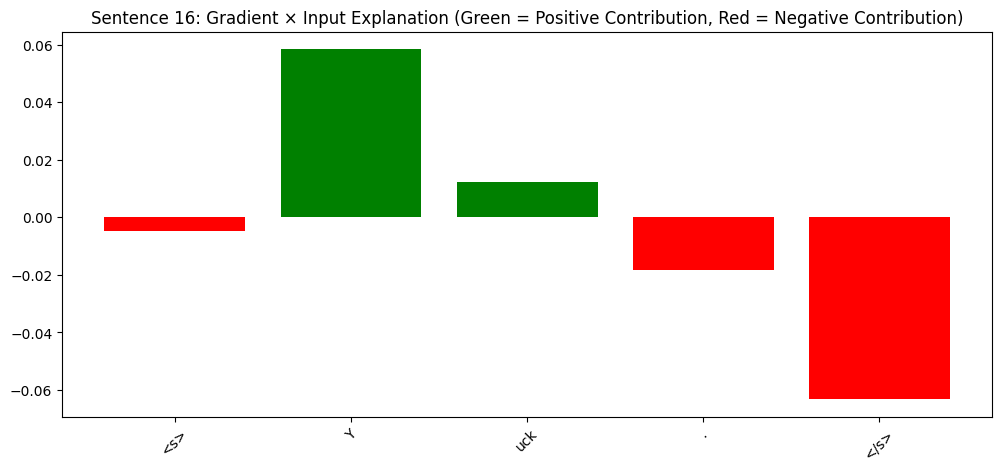


SENTENCE 17/18
Text: It is a total disgrace.
Predicted Emotion: sadness


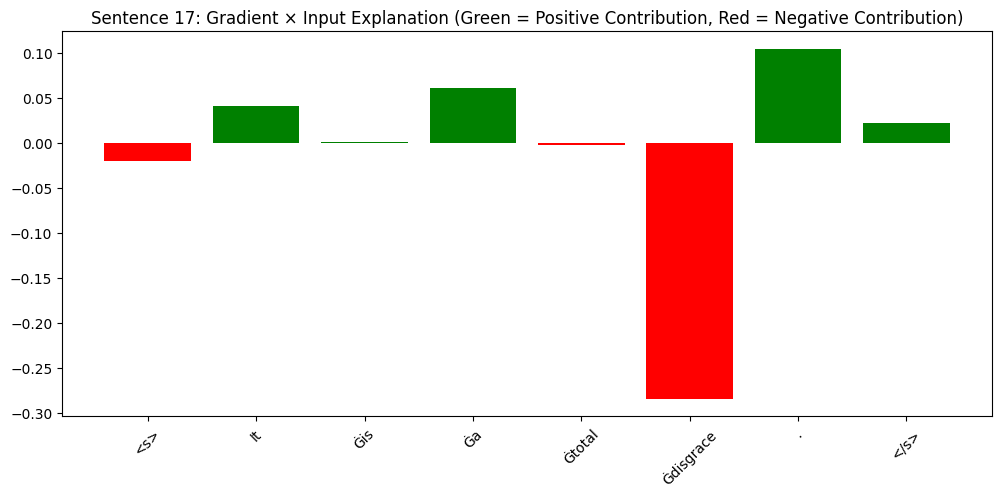


SENTENCE 18/18
Text: Ah, shit!
Predicted Emotion: anger


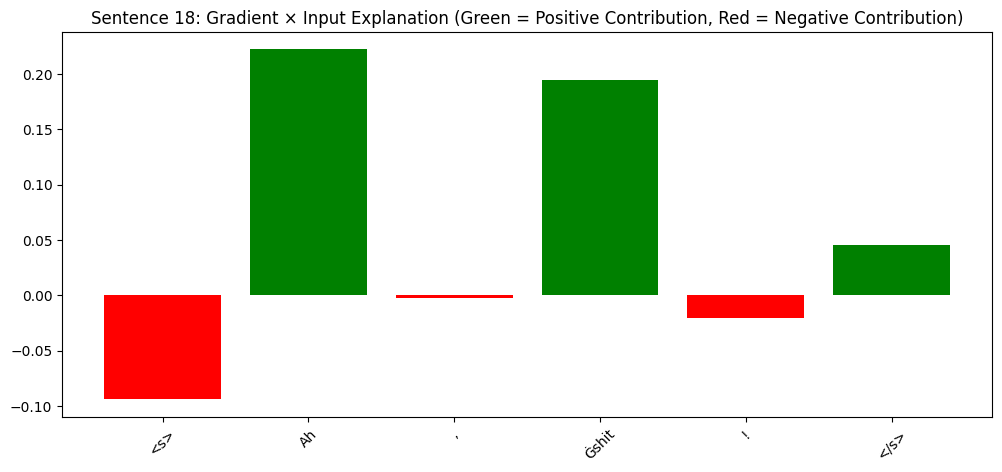

In [9]:
# Sample sentence for testing
# TODO: change this code block to run visualisations on your sentences!
# TODO: These are interesting visuals for your presentation. Why did you choose these sentences? Did you expect these outcomes? What does this tell you? 

# TODO SOLUTION: Put all your sentences here
all_sentences = [
    # HAPPINESS
    "I thought it was fantastic. It was incredibly fun.", 
    "A thousand euros! Congratulations.",  
    "I can imagine that you are sitting across from me with a feeling of pride.",
    
    # SADNESS
    "With every dropout who leaves, the farewell affects the group value.",
    "Too bad. Yes.",
    "Gone as her prime suspect.",
    
    # ANGER
    "You are a dirty sneak.",
    "Fuck you's.",
    "I thought you were the bitch.",
    
    # FEAR
    "fear struck me to the heart.",
    "Although that is very scary.",
    "I find this a very exciting test.",
    
    # SURPRISE
    "Wow. Jeez.",
    "Oh my God!",
    "Hey wait a minute, Taken is shouting whenever he sees something.",
    
    # DISGUST
    "Yuck.",
    "It is a total disgrace.",
    "Ah, shit!",
]

for sentence_num, text in enumerate(all_sentences, 1):
    print(f"\n{'='*60}")
    print(f"SENTENCE {sentence_num}/{len(all_sentences)}")
    print(f"Text: {text}")
    print(f"{'='*60}")
    
    inputs = tokenizer(text, return_tensors='pt')

    # Get model prediction
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=-1).item()

    # Get emotion labels from model's config
    emotion_labels = model.config.id2label
    predicted_emotion = emotion_labels[predicted_class]
    print(f"Predicted Emotion: {predicted_emotion}")

    # Gradient x Input Explanation with Color-Coded Bars
    relevance_scores = gradient_x_input(model, inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

    # Sum across embedding dimensions to get per-token relevance
    token_relevance = relevance_scores[0].sum(dim=-1).detach().numpy()

    # Add color for positive/negative contribution based on summed relevance
    colors = ['green' if score > 0 else 'red' for score in token_relevance]

    plt.figure(figsize=(12, 5))
    plt.bar(tokens, token_relevance, color=colors)
    plt.title(f"Sentence {sentence_num}: Gradient × Input Explanation (Green = Positive Contribution, Red = Negative Contribution)")
    plt.xticks(rotation=45)
    plt.show()

### Attention Scores

The attention scores heatmap visualizes how much each token in the input sequence influences other tokens during the model’s prediction. The rows represent the query tokens (the tokens seeking information), and the columns represent the key tokens (the tokens being attended to). The color intensity shows the strength of attention: dark red indicates strong attention, while dark blue indicates weak attention. A strong diagonal line suggests that the model is relying on self-attention, where each token is primarily focused on itself. High attention values between specific tokens indicate that the model considers them strongly related. Strong attention on a token suggests that the model recognizes its emotional importance. Scattered attention suggests the model is considering broader context, while concentrated attention on specific tokens shows that the model is focusing on particular details. The heatmap reflects how the model processes and builds relationships between tokens to understand context and meaning.

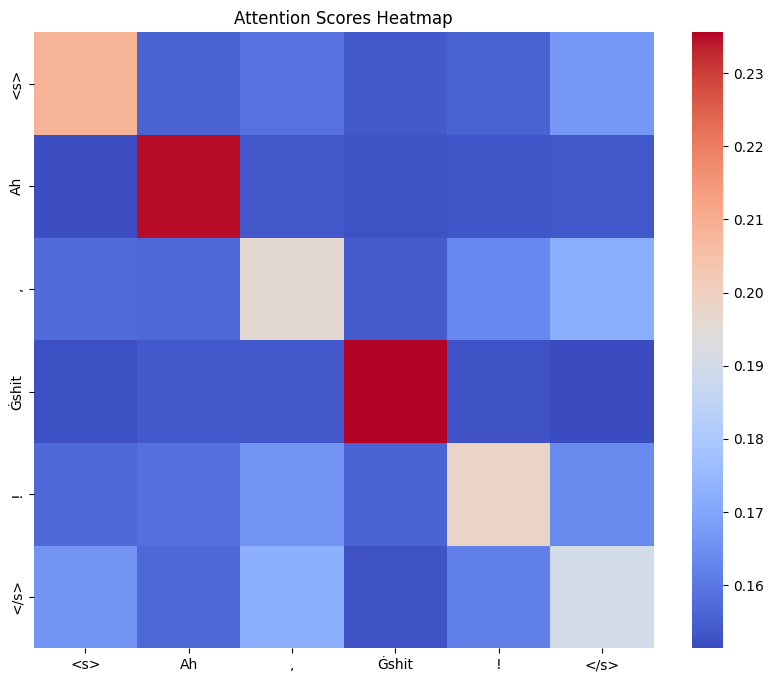

In [11]:
def visualize_attention_and_relevance(attention_probs, relevance_scores, tokens):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_probs.detach().numpy(), cmap='coolwarm', 
                xticklabels=tokens, yticklabels=tokens)
    plt.title('Attention Scores Heatmap')
    plt.show()

# Modify attention propagation function to add visualization:
def modified_attention_forward(attention_layer, hidden_states, relevance_scores, tokens):
    attention_scores = (hidden_states @ hidden_states.transpose(-1, -2)) / hidden_states.size(-1)**0.5
    attention_probs = attention_scores.softmax(dim=-1).detach()
    context_layer = attention_probs @ hidden_states
    propagated_relevance = (attention_probs.transpose(-1, -2) @ relevance_scores)

    # Visualise
    visualize_attention_and_relevance(attention_probs[0].detach(), 
                                     propagated_relevance[0].detach(), 
                                     tokens)

    return context_layer, propagated_relevance

# Get tokens from tokenizer
tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

# Get hidden states and relevance scores
inputs_embeds = model.get_input_embeddings()(inputs.input_ids)
hidden_states = inputs_embeds.clone().detach().requires_grad_(True)

# Start relevance from the predicted class activation
predicted_class = outputs.logits.argmax(dim=-1)
relevance_scores = torch.zeros_like(hidden_states)
# Fix: index the logits correctly for the predicted class
relevance_scores[:, -1, :] = outputs.logits[0, predicted_class[0]].unsqueeze(0)

# Run modified attention with visualization (CHANGED: bert → roberta)
context_layer, propagated_relevance = modified_attention_forward(
    model.roberta.encoder.layer[0].attention.self, 
    hidden_states, 
    relevance_scores,
    tokens
)

### Model confidence during Token Removal

This code generates a plot that shows how the model’s confidence changes as tokens are progressively removed from the input. First, it ensures that the length of the token list and the confidence scores are aligned by setting min_length to the smaller of the two. Then, ``confidences_remove``, which contains the model’s confidence levels after each token removal, is converted to a NumPy array for compatibility with plotting functions.

The ``plt.plot()`` function creates a line plot where the x-axis represents the number of tokens removed and the y-axis shows the model’s confidence in its prediction. The plot shows how the model’s confidence changes after each token removal, helping to identify which tokens were most critical for the prediction.

A horizontal red line is drawn at a confidence level of 0.5 using ``plt.axhline()``, representing the threshold where the model’s confidence drops to a point where the prediction becomes uncertain. plt.fill_between() shades the area below 0.5 in red, visually highlighting where the model’s confidence drops below the threshold. This visualization helps reveal which tokens are most influential in maintaining the model’s confidence and where the prediction starts to break down as critical tokens are removed.

**TODO: Can you explain what this means? How is the removal applied? What does the 0.5 threshold represent and why is this important?**

In [ ]:
# Get the original prediction to track
original_predicted_class = outputs.logits.argmax(dim=-1).item()
all_probs = outputs.logits.softmax(dim=-1)[0]

print(f"Text: {text}")
print(f"\nAll predictions:")
for idx, prob in enumerate(all_probs):
    emotion = model.config.id2label[idx]
    marker = " <-- PREDICTED" if idx == original_predicted_class else ""
    print(f"  {emotion}: {prob.item():.4f}{marker}")

print(f"\nTracking confidence for: {model.config.id2label[original_predicted_class]}")

# Run function - note new signature
confidences_remove = perturb_input_and_evaluate(model, tokenizer, text, inputs, outputs, 'most')

# Adjust length if mismatched
min_length = min(len(tokens) + 1, len(confidences_remove))

# Convert list to numpy array
confidences_remove = np.array(confidences_remove)

plt.figure(figsize=(12, 5))
# Start from 0 tokens removed
plt.plot(range(0, min_length), confidences_remove[:min_length], marker='o', color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', label="50% Confidence Threshold")
plt.fill_between(
    range(0, min_length), 
    confidences_remove[:min_length], 
    0.5, 
    where=(confidences_remove[:min_length] < 0.5), 
    color='red', 
    alpha=0.2
)
plt.title(f"Model Confidence for '{model.config.id2label[original_predicted_class]}' During Token Removal")
plt.xlabel("Number of Tokens Removed")
plt.ylabel(f"Confidence for Original Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nConfidence values: {confidences_remove[:min_length]}")
print(f"Starting confidence: {confidences_remove[0]:.4f} ({confidences_remove[0]*100:.2f}%)")

In [ ]:
# Comparison: Remove LEAST relevant tokens first
print("\n" + "="*60)
print("COMPARISON: Removing LEAST relevant tokens first")
print("="*60)

# Run function with 'least' parameter
confidences_remove_least = perturb_input_and_evaluate(model, tokenizer, text, inputs, outputs, 'least')

# Adjust length if mismatched
min_length = min(len(tokens) + 1, len(confidences_remove_least))

# Convert list to numpy array
confidences_remove_least = np.array(confidences_remove_least)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Remove MOST relevant first
ax1.plot(range(0, min_length), confidences_remove[:min_length], marker='o', color='blue', linewidth=2)
ax1.axhline(y=0.5, color='red', linestyle='--', label="50% Confidence Threshold")
ax1.fill_between(
    range(0, min_length), 
    confidences_remove[:min_length], 
    0.5, 
    where=(confidences_remove[:min_length] < 0.5), 
    color='red', 
    alpha=0.2
)
ax1.set_title(f"Removing MOST Relevant Tokens First\n(Prediction: {model.config.id2label[original_predicted_class]})", fontsize=12)
ax1.set_xlabel("Number of Tokens Removed")
ax1.set_ylabel("Confidence for Original Prediction")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Remove LEAST relevant first
ax2.plot(range(0, min_length), confidences_remove_least[:min_length], marker='o', color='green', linewidth=2)
ax2.axhline(y=0.5, color='red', linestyle='--', label="50% Confidence Threshold")
ax2.fill_between(
    range(0, min_length), 
    confidences_remove_least[:min_length], 
    0.5, 
    where=(confidences_remove_least[:min_length] < 0.5), 
    color='red', 
    alpha=0.2
)
ax2.set_title(f"Removing LEAST Relevant Tokens First\n(Prediction: {model.config.id2label[original_predicted_class]})", fontsize=12)
ax2.set_xlabel("Number of Tokens Removed")
ax2.set_ylabel("Confidence for Original Prediction")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMost relevant first: {confidences_remove[:min_length]}")
print(f"Least relevant first: {confidences_remove_least[:min_length]}")